# Comprehensive Performance Analysis: RQ1 & RQ2

This notebook provides a complete analysis across all experimental dimensions:

## Dimensions Analyzed
- **Tasks**: Code Generation, Vulnerability Detection, Log Analysis
- **Designs**: SA (Single-Agent), DA (Dual-Agent), MA (Multi-Agent)
- **Prompting**: Zero-shot vs Few-shot
- **Modes**: Instruct vs Thinking (reasoning)
- **Model Sizes**: 4B, 8B, 30B, 49B parameters

## Models
- Qwen3-4B-Instruct / Qwen3-4B-Thinking
- Nemotron-Nano-8B (Instruct / Thinking)
- Qwen3-30B-A3B-Instruct / Qwen3-30B-A3B-Thinking
- Nemotron-Super-49B (Instruct / Thinking)

**Date**: January 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Base paths
from pathlib import Path
BASE_DIR = Path('..').resolve()
RESULTS_DIR = BASE_DIR / 'results'
ANALYSIS_DIR = RESULTS_DIR / 'analysis_comprehensive'
ANALYSIS_DIR.mkdir(exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")
print(f"Analysis output: {ANALYSIS_DIR}")

Results directory: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results
Analysis output: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive


## 1. Load and Prepare Data

In [2]:
# Load consolidated performance data
perf_df = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')

print(f"Total experiments: {len(perf_df)}")
print(f"\nBreakdown by task:")
print(perf_df['task'].value_counts())
print(f"\nBreakdown by design:")
print(perf_df['design'].value_counts())

Total experiments: 120

Breakdown by task:
task
code_generation            48
vulnerability_detection    48
log_analysis               24
Name: count, dtype: int64

Breakdown by design:
design
DA    40
MA    40
SA    40
Name: count, dtype: int64


In [3]:
# Create unified performance metric column
# - Code generation: pass_at_1
# - Vulnerability detection: f1_score
# - Log analysis: f1_score

def get_primary_metric(row):
    if row['task'] == 'code_generation':
        return row['pass_at_1']
    else:
        return row['f1_score']

perf_df['primary_metric'] = perf_df.apply(get_primary_metric, axis=1)
perf_df['primary_metric_pct'] = perf_df['primary_metric'] * 100
perf_df['accuracy_pct'] = perf_df['accuracy'] * 100
perf_df['f1_pct'] = perf_df['f1_score'] * 100

# Create short labels
def make_short_label(row):
    params = int(row['parameters_b'])
    mode = 'T' if row['mode'] == 'thinking' else 'I'
    prompt = 'F' if row['prompting'] == 'few-shot' else 'Z'
    return f"{params}B-{mode}-{prompt}"

perf_df['short_label'] = perf_df.apply(make_short_label, axis=1)

# Display sample
perf_df[['short_label', 'task', 'design', 'primary_metric_pct']].head(10)

,short_label,task,design,primary_metric_pct
0,4B-I-F,code_generation,DA,99.390244
1,4B-I-Z,code_generation,DA,89.634146
2,4B-T-F,code_generation,DA,88.414634
3,4B-T-Z,code_generation,DA,90.853659
4,4B-I-F,log_analysis,DA,6.172840
5,4B-I-Z,log_analysis,DA,5.917160
6,4B-T-F,log_analysis,DA,6.185567
7,4B-T-Z,log_analysis,DA,7.058824
8,4B-I-F,vulnerability_detection,DA,44.759207
9,4B-I-Z,vulnerability_detection,DA,57.142857


## 2. Color and Style Configuration

In [4]:
# Color palettes
MODEL_COLORS = {
    4: '#3498db',    # Blue for 4B
    8: '#00bcd4',    # Cyan for 8B
    30: '#9b59b6',   # Purple for 30B
    49: '#e91e63',   # Magenta for 49B
}

DESIGN_COLORS = {
    'SA': '#2ecc71',  # Green
    'DA': '#3498db',  # Blue
    'MA': '#e74c3c',  # Red
}

TASK_COLORS = {
    'code_generation': '#3498db',
    'vulnerability_detection': '#e74c3c',
    'log_analysis': '#f39c12',
}

PROMPTING_COLORS = {
    'zero-shot': '#95a5a6',
    'few-shot': '#2c3e50',
}

MODE_HATCHES = {
    'instruct': '',
    'thinking': '//',
}

TASK_LABELS = {
    'code_generation': 'Code Generation',
    'vulnerability_detection': 'Vulnerability Detection',
    'log_analysis': 'Log Analysis',
}

METRIC_LABELS = {
    'code_generation': 'Pass@1 (%)',
    'vulnerability_detection': 'F1 Score (%)',
    'log_analysis': 'F1 Score (%)',
}

print("Color configuration loaded.")

Color configuration loaded.


## 3. Performance by Task (Overview)

PERFORMANCE SUMMARY BY TASK
                        primary_metric_pct                       accuracy_pct  \
                                      mean    std    min     max         mean   
task                                                                            
code_generation                      95.24   4.07  86.59  100.00          NaN   
log_analysis                          5.18   1.76   0.00    8.45        30.43   
vulnerability_detection              49.66  17.89   0.00   66.90        51.52   

                                              
                           std    min    max  
task                                          
code_generation            NaN    NaN    NaN  
log_analysis             23.99   3.38  94.29  
vulnerability_detection   2.22  47.93  56.25  


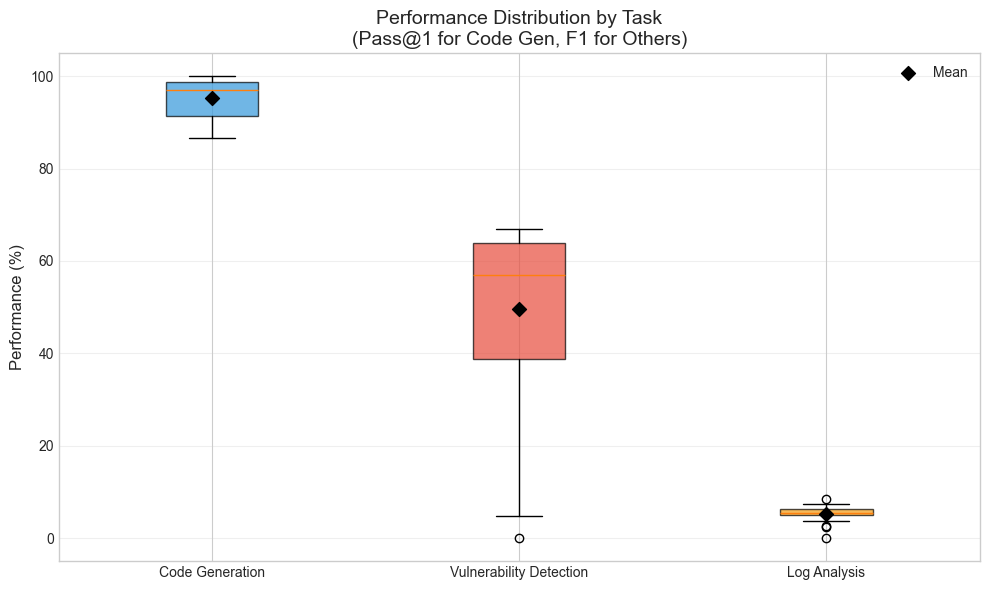

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/task_performance_boxplot.png


In [5]:
# Summary statistics by task
task_summary = perf_df.groupby('task').agg({
    'primary_metric_pct': ['mean', 'std', 'min', 'max'],
    'accuracy_pct': ['mean', 'std', 'min', 'max']
}).round(2)

print("="*80)
print("PERFORMANCE SUMMARY BY TASK")
print("="*80)
print(task_summary)

# Box plot by task
fig, ax = plt.subplots(figsize=(10, 6))

tasks_order = ['code_generation', 'vulnerability_detection', 'log_analysis']
task_data = [perf_df[perf_df['task'] == t]['primary_metric_pct'].dropna() for t in tasks_order]

bp = ax.boxplot(task_data, patch_artist=True, labels=[TASK_LABELS[t] for t in tasks_order])

# Color boxes
for patch, task in zip(bp['boxes'], tasks_order):
    patch.set_facecolor(TASK_COLORS[task])
    patch.set_alpha(0.7)

ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_title('Performance Distribution by Task\n(Pass@1 for Code Gen, F1 for Others)', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Add mean markers
means = [d.mean() for d in task_data]
ax.scatter(range(1, 4), means, marker='D', color='black', s=50, zorder=5, label='Mean')
ax.legend()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'task_performance_boxplot.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'task_performance_boxplot.png'}")

## 4. Design Comparison (SA vs DA vs MA)

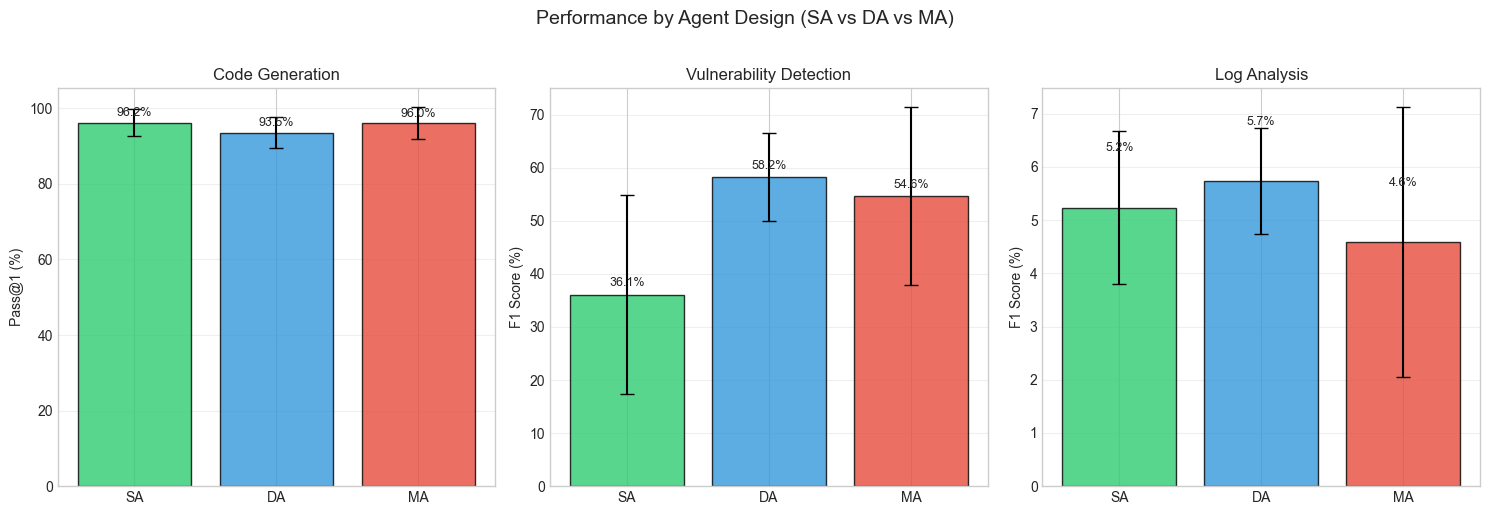

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/design_comparison_by_task.png


In [6]:
# Performance by design for each task
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = perf_df[perf_df['task'] == task]
    
    # Group by design
    design_means = task_df.groupby('design')['primary_metric_pct'].mean()
    design_stds = task_df.groupby('design')['primary_metric_pct'].std()
    
    designs = ['SA', 'DA', 'MA']
    x = range(len(designs))
    
    bars = ax.bar(x, [design_means.get(d, 0) for d in designs],
                  yerr=[design_stds.get(d, 0) for d in designs],
                  color=[DESIGN_COLORS[d] for d in designs],
                  edgecolor='black', linewidth=1, capsize=5, alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(designs)
    ax.set_ylabel(METRIC_LABELS[task])
    ax.set_title(TASK_LABELS[task])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, [design_means.get(d, 0) for d in designs]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Performance by Agent Design (SA vs DA vs MA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'design_comparison_by_task.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'design_comparison_by_task.png'}")

In [7]:
# Design comparison table
design_task_summary = perf_df.groupby(['task', 'design']).agg({
    'primary_metric_pct': 'mean',
    'accuracy_pct': 'mean'
}).round(2).unstack(level=0)

print("="*80)
print("MEAN PERFORMANCE BY DESIGN AND TASK")
print("="*80)
print(design_task_summary)

MEAN PERFORMANCE BY DESIGN AND TASK
       primary_metric_pct                                       \
task      code_generation log_analysis vulnerability_detection   
design                                                           
DA                  93.49         5.73                   58.24   
MA                  96.04         4.58                   54.61   
SA                  96.19         5.24                   36.12   

          accuracy_pct                                       
task   code_generation log_analysis vulnerability_detection  
design                                                       
DA                 NaN        25.71                   50.70  
MA                 NaN        47.50                   51.40  
SA                 NaN        18.08                   52.48  


## 5. Prompting Strategy Comparison (Zero-shot vs Few-shot)

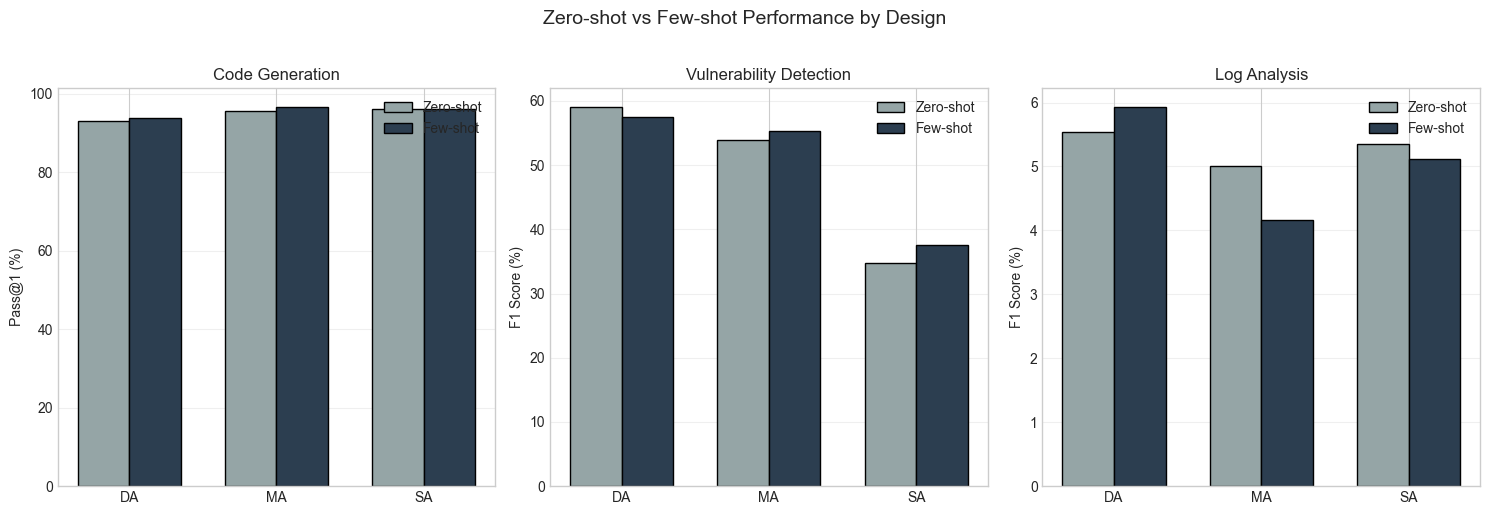

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/prompting_comparison_by_task.png


In [8]:
# Performance by prompting strategy for each task
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = perf_df[perf_df['task'] == task]
    
    # Group by prompting and design
    grouped = task_df.groupby(['design', 'prompting'])['primary_metric_pct'].mean().unstack()
    
    x = np.arange(len(grouped.index))
    width = 0.35
    
    if 'zero-shot' in grouped.columns:
        bars1 = ax.bar(x - width/2, grouped['zero-shot'], width, 
                       label='Zero-shot', color=PROMPTING_COLORS['zero-shot'],
                       edgecolor='black', linewidth=1)
    if 'few-shot' in grouped.columns:
        bars2 = ax.bar(x + width/2, grouped['few-shot'], width,
                       label='Few-shot', color=PROMPTING_COLORS['few-shot'],
                       edgecolor='black', linewidth=1)
    
    ax.set_xticks(x)
    ax.set_xticklabels(grouped.index)
    ax.set_ylabel(METRIC_LABELS[task])
    ax.set_title(TASK_LABELS[task])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Zero-shot vs Few-shot Performance by Design', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'prompting_comparison_by_task.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'prompting_comparison_by_task.png'}")

In [9]:
# Prompting comparison table
prompting_summary = perf_df.groupby(['task', 'prompting']).agg({
    'primary_metric_pct': 'mean'
}).round(2).unstack(level=1)

prompting_summary['delta'] = prompting_summary[('primary_metric_pct', 'few-shot')] - prompting_summary[('primary_metric_pct', 'zero-shot')]

print("="*80)
print("PROMPTING STRATEGY COMPARISON")
print("="*80)
print(prompting_summary)
print("\nPositive delta = Few-shot outperforms Zero-shot")

PROMPTING STRATEGY COMPARISON
                        primary_metric_pct           delta
prompting                         few-shot zero-shot      
task                                                      
code_generation                      95.53     94.95  0.58
log_analysis                          5.07      5.30 -0.23
vulnerability_detection              50.09     49.23  0.86

Positive delta = Few-shot outperforms Zero-shot


## 6. Mode Comparison (Instruct vs Thinking)

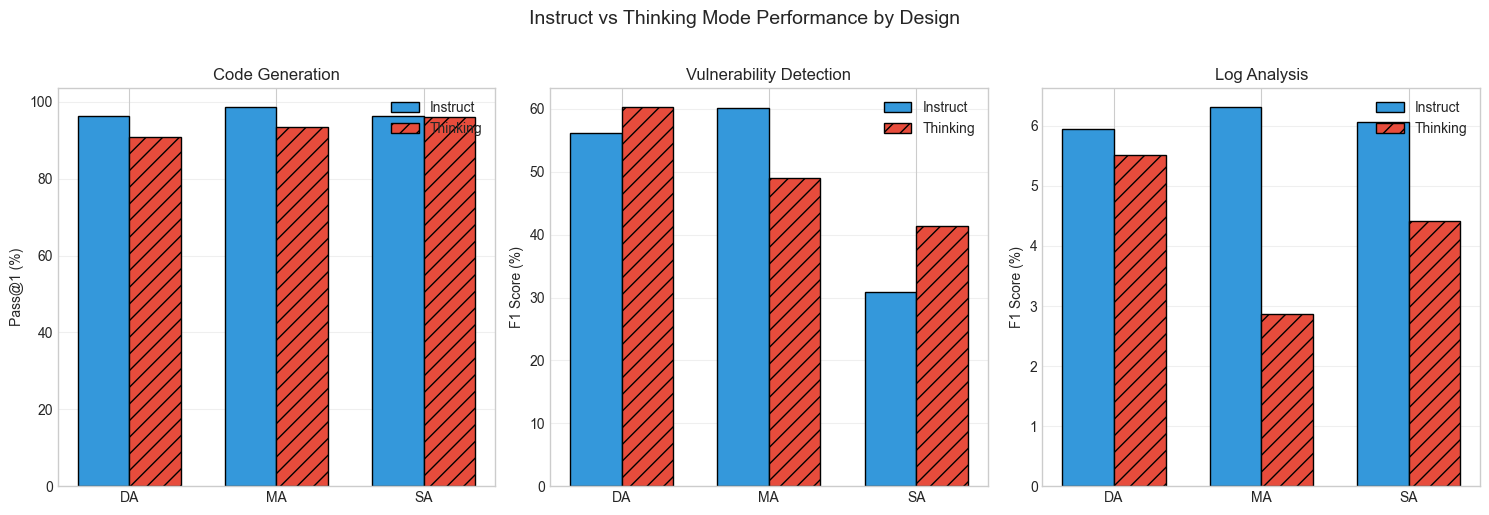

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/mode_comparison_by_task.png


In [10]:
# Performance by mode for each task
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mode_colors = {'instruct': '#3498db', 'thinking': '#e74c3c'}

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = perf_df[perf_df['task'] == task]
    
    # Group by mode and design
    grouped = task_df.groupby(['design', 'mode'])['primary_metric_pct'].mean().unstack()
    
    x = np.arange(len(grouped.index))
    width = 0.35
    
    if 'instruct' in grouped.columns:
        bars1 = ax.bar(x - width/2, grouped['instruct'], width,
                       label='Instruct', color=mode_colors['instruct'],
                       edgecolor='black', linewidth=1)
    if 'thinking' in grouped.columns:
        bars2 = ax.bar(x + width/2, grouped['thinking'], width,
                       label='Thinking', color=mode_colors['thinking'],
                       edgecolor='black', linewidth=1, hatch='//')
    
    ax.set_xticks(x)
    ax.set_xticklabels(grouped.index)
    ax.set_ylabel(METRIC_LABELS[task])
    ax.set_title(TASK_LABELS[task])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Instruct vs Thinking Mode Performance by Design', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'mode_comparison_by_task.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'mode_comparison_by_task.png'}")

In [11]:
# Mode comparison table
mode_summary = perf_df.groupby(['task', 'mode']).agg({
    'primary_metric_pct': 'mean'
}).round(2).unstack(level=1)

mode_summary['delta'] = mode_summary[('primary_metric_pct', 'thinking')] - mode_summary[('primary_metric_pct', 'instruct')]

print("="*80)
print("MODE COMPARISON (INSTRUCT vs THINKING)")
print("="*80)
print(mode_summary)
print("\nPositive delta = Thinking outperforms Instruct")

MODE COMPARISON (INSTRUCT vs THINKING)
                        primary_metric_pct          delta
mode                              instruct thinking      
task                                                     
code_generation                      97.05    93.43 -3.62
log_analysis                          6.11     4.26 -1.85
vulnerability_detection              49.11    50.21  1.10

Positive delta = Thinking outperforms Instruct


## 7. Model Size Scaling Analysis

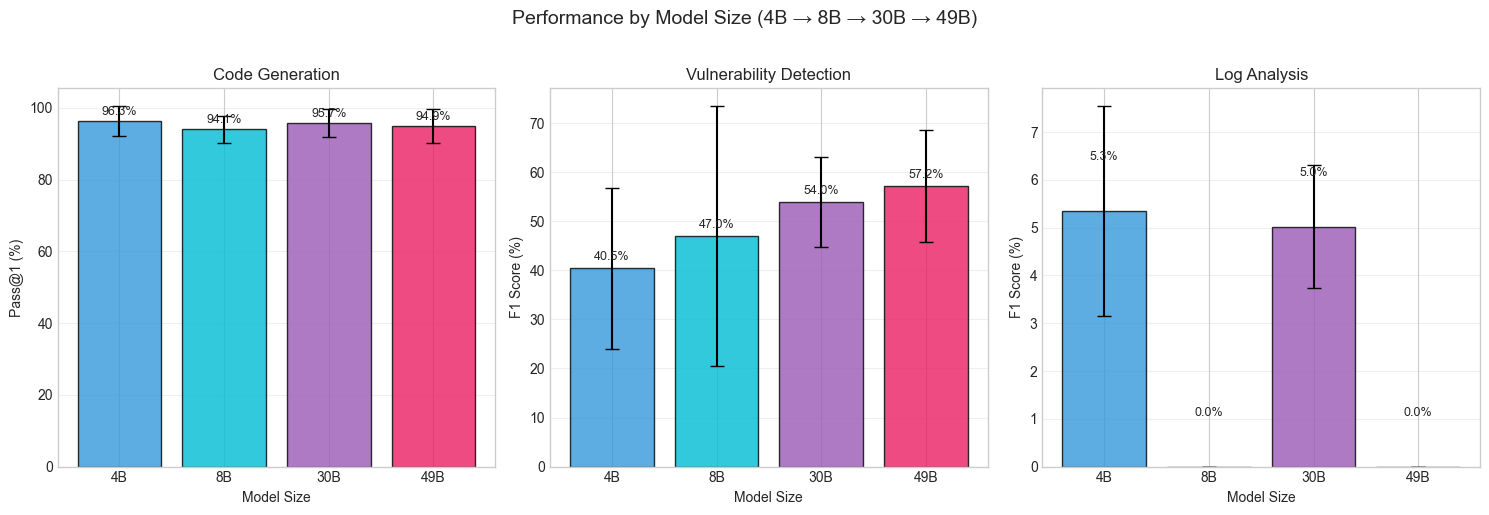

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/model_size_scaling.png


In [12]:
# Performance by model size for each task
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_sizes = [4, 8, 30, 49]

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = perf_df[perf_df['task'] == task]
    
    # Group by model size
    size_means = task_df.groupby('parameters_b')['primary_metric_pct'].mean()
    size_stds = task_df.groupby('parameters_b')['primary_metric_pct'].std()
    
    x = range(len(model_sizes))
    bars = ax.bar(x, [size_means.get(s, 0) for s in model_sizes],
                  yerr=[size_stds.get(s, 0) for s in model_sizes],
                  color=[MODEL_COLORS[s] for s in model_sizes],
                  edgecolor='black', linewidth=1, capsize=5, alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}B' for s in model_sizes])
    ax.set_xlabel('Model Size')
    ax.set_ylabel(METRIC_LABELS[task])
    ax.set_title(TASK_LABELS[task])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, [size_means.get(s, 0) for s in model_sizes]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

fig.suptitle('Performance by Model Size (4B → 8B → 30B → 49B)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'model_size_scaling.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'model_size_scaling.png'}")

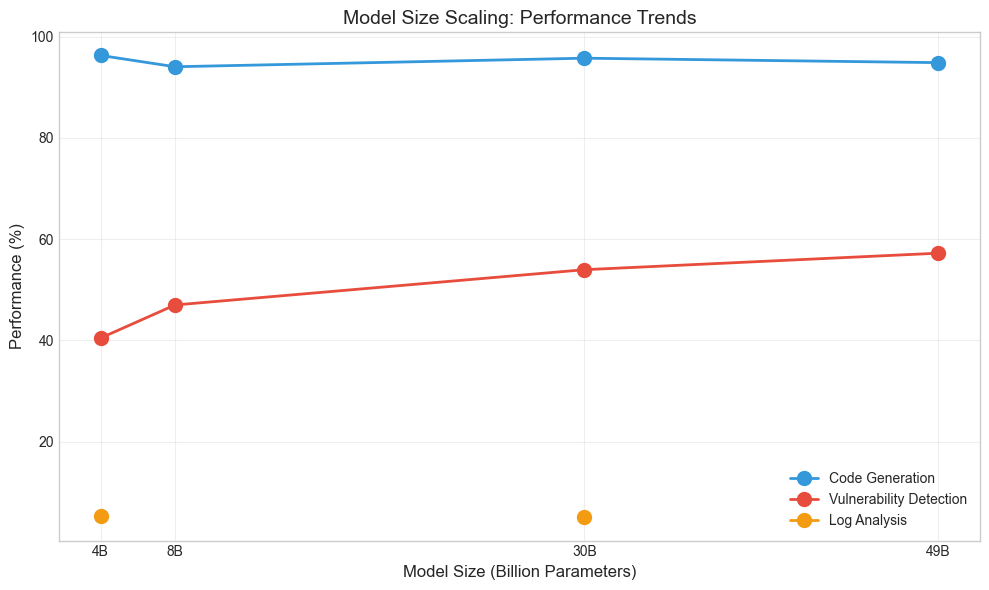

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/model_size_scaling_lines.png


In [13]:
# Model size scaling line plot
fig, ax = plt.subplots(figsize=(10, 6))

for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    size_means = task_df.groupby('parameters_b')['primary_metric_pct'].mean()
    
    ax.plot(model_sizes, [size_means.get(s, np.nan) for s in model_sizes],
            marker='o', markersize=10, linewidth=2,
            color=TASK_COLORS[task], label=TASK_LABELS[task])

ax.set_xlabel('Model Size (Billion Parameters)', fontsize=12)
ax.set_ylabel('Performance (%)', fontsize=12)
ax.set_title('Model Size Scaling: Performance Trends', fontsize=14)
ax.set_xticks(model_sizes)
ax.set_xticklabels([f'{s}B' for s in model_sizes])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'model_size_scaling_lines.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'model_size_scaling_lines.png'}")

## 8. Heatmap: Full Experiment Matrix

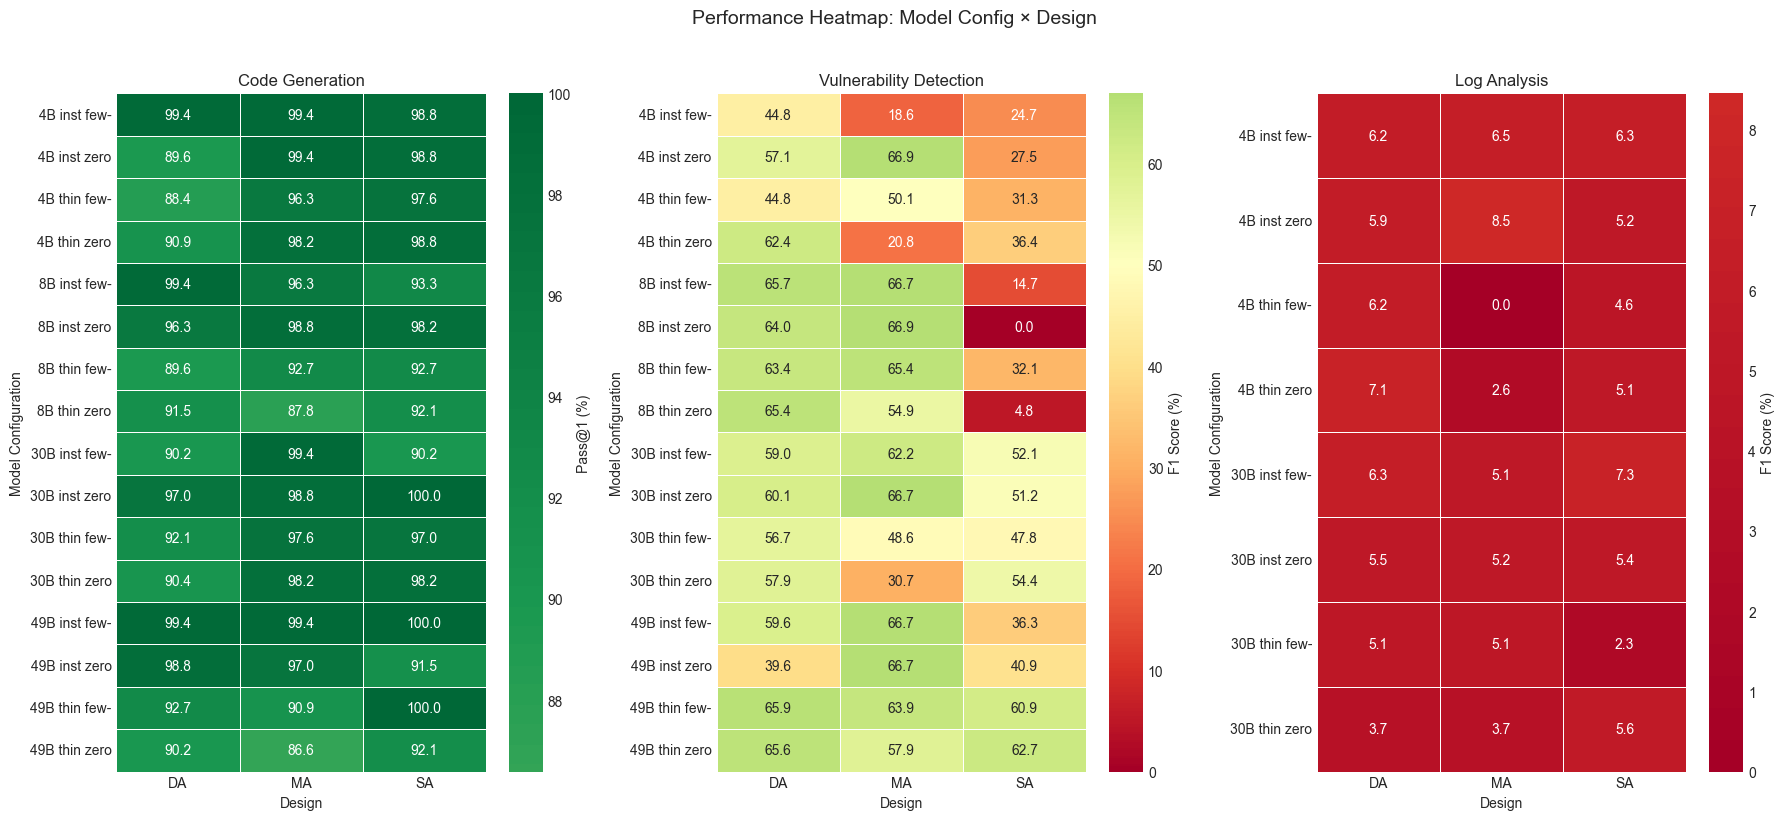

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/performance_heatmap.png


In [14]:
# Create heatmap for each task
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = perf_df[perf_df['task'] == task].copy()
    
    # Create pivot table: rows = model config, cols = design
    task_df['config'] = task_df.apply(
        lambda r: f"{int(r['parameters_b'])}B {r['mode'][:4]} {r['prompting'][:4]}", axis=1)
    
    pivot = task_df.pivot_table(
        values='primary_metric_pct',
        index='config',
        columns='design',
        aggfunc='mean'
    )
    
    # Sort by model size
    pivot = pivot.reindex(sorted(pivot.index, key=lambda x: int(x.split('B')[0])))
    
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', 
                center=50, ax=ax, cbar_kws={'label': METRIC_LABELS[task]},
                linewidths=0.5, linecolor='white')
    
    ax.set_title(TASK_LABELS[task], fontsize=12)
    ax.set_xlabel('Design')
    ax.set_ylabel('Model Configuration')

fig.suptitle('Performance Heatmap: Model Config × Design', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'performance_heatmap.png', bbox_inches='tight')
plt.show()
print(f"Saved: {ANALYSIS_DIR / 'performance_heatmap.png'}")

## 9. Best Configuration Analysis

In [15]:
print("="*80)
print("BEST CONFIGURATIONS BY TASK")
print("="*80)

for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    best_idx = task_df['primary_metric_pct'].idxmax()
    best = task_df.loc[best_idx]
    
    print(f"\n{TASK_LABELS[task]}:")
    print(f"  Best: {best['model']} | {best['design']} | {best['mode']} | {best['prompting']}")
    print(f"  Performance: {best['primary_metric_pct']:.2f}%")
    
    # Also show worst
    worst_idx = task_df['primary_metric_pct'].idxmin()
    worst = task_df.loc[worst_idx]
    print(f"  Worst: {worst['model']} | {worst['design']} | {worst['mode']} | {worst['prompting']}")
    print(f"  Performance: {worst['primary_metric_pct']:.2f}%")
    print(f"  Range: {best['primary_metric_pct'] - worst['primary_metric_pct']:.2f}%")

BEST CONFIGURATIONS BY TASK

Code Generation:
  Best: Qwen3-30B-A3B-Instruct | SA | instruct | zero-shot
  Performance: 100.00%
  Worst: Nemotron-Super-49B | MA | thinking | zero-shot
  Performance: 86.59%
  Range: 13.41%

Vulnerability Detection:
  Best: Qwen3-4B-Instruct | MA | instruct | zero-shot
  Performance: 66.90%
  Worst: Nemotron-Nano-8B | SA | instruct | zero-shot
  Performance: 0.00%
  Range: 66.90%

Log Analysis:
  Best: Qwen3-4B-Instruct | MA | instruct | zero-shot
  Performance: 8.45%
  Worst: Qwen3-4B-Thinking | MA | thinking | few-shot
  Performance: 0.00%
  Range: 8.45%


In [16]:
# Top 5 configurations per task
print("="*80)
print("TOP 5 CONFIGURATIONS PER TASK")
print("="*80)

for task in tasks_order:
    print(f"\n{TASK_LABELS[task]}:")
    task_df = perf_df[perf_df['task'] == task].nlargest(5, 'primary_metric_pct')
    for i, (_, row) in enumerate(task_df.iterrows(), 1):
        print(f"  {i}. {row['short_label']} | {row['design']} | {row['primary_metric_pct']:.2f}%")

TOP 5 CONFIGURATIONS PER TASK

Code Generation:
  1. 30B-I-Z | SA | 100.00%
  2. 49B-I-F | SA | 100.00%
  3. 49B-T-F | SA | 100.00%
  4. 4B-I-F | DA | 99.39%
  5. 4B-I-F | MA | 99.39%

Vulnerability Detection:
  1. 4B-I-Z | MA | 66.90%
  2. 8B-I-Z | MA | 66.90%
  3. 8B-I-F | MA | 66.67%
  4. 30B-I-Z | MA | 66.67%
  5. 49B-I-F | MA | 66.67%

Log Analysis:
  1. 4B-I-Z | MA | 8.45%
  2. 30B-I-F | SA | 7.27%
  3. 4B-T-Z | DA | 7.06%
  4. 4B-I-F | MA | 6.48%
  5. 4B-I-F | SA | 6.27%


## 10. Summary Statistics

In [17]:
# Comprehensive summary table
summary_table = perf_df.groupby(['task', 'design', 'mode', 'prompting']).agg({
    'primary_metric_pct': 'mean',
    'parameters_b': 'first'  # Just to show we have data
}).round(2)

print("="*80)
print("FULL EXPERIMENT SUMMARY")
print("="*80)
print(summary_table.to_string())

FULL EXPERIMENT SUMMARY
                                                   primary_metric_pct  parameters_b
task                    design mode     prompting                                  
code_generation         DA     instruct few-shot                97.10             4
                                        zero-shot               95.43             4
                               thinking few-shot                90.70             4
                                        zero-shot               90.74             4
                        MA     instruct few-shot                98.63             4
                                        zero-shot               98.48             4
                               thinking few-shot                94.36             4
                                        zero-shot               92.68             4
                        SA     instruct few-shot                95.58             4
                                        zero-shot   

In [18]:
# Save all outputs
perf_df.to_csv(ANALYSIS_DIR / 'comprehensive_performance_data.csv', index=False)
summary_table.to_csv(ANALYSIS_DIR / 'comprehensive_summary.csv')

print(f"\nSaved data to: {ANALYSIS_DIR}")
print("\nGenerated files:")
for f in sorted(ANALYSIS_DIR.glob('*')):
    print(f"  - {f.name}")


Saved data to: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive

Generated files:
  - comprehensive_performance_data.csv
  - comprehensive_summary.csv
  - design_comparison_by_task.png
  - mode_comparison_by_task.png
  - model_size_scaling.png
  - model_size_scaling_lines.png
  - performance_heatmap.png
  - performance_vs_energy_scatter.png
  - prompting_comparison_by_task.png
  - scatter_code_generation_energy.png
  - scatter_log_analysis_energy.png
  - scatter_vulnerability_detection_energy.png
  - task_performance_boxplot.png


## 11. Key Findings Summary

In [19]:
print("="*80)
print("KEY FINDINGS")
print("="*80)

# 1. Task difficulty
print("\n1. TASK DIFFICULTY RANKING:")
task_means = perf_df.groupby('task')['primary_metric_pct'].mean().sort_values(ascending=False)
for task, mean in task_means.items():
    print(f"   {TASK_LABELS[task]}: {mean:.2f}%")

# 2. Best design per task
print("\n2. OPTIMAL DESIGN PER TASK:")
for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    best_design = task_df.groupby('design')['primary_metric_pct'].mean().idxmax()
    best_val = task_df.groupby('design')['primary_metric_pct'].mean().max()
    print(f"   {TASK_LABELS[task]}: {best_design} ({best_val:.2f}%)")

# 3. Prompting effect
print("\n3. PROMPTING EFFECT (Few-shot vs Zero-shot):")
for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    few = task_df[task_df['prompting'] == 'few-shot']['primary_metric_pct'].mean()
    zero = task_df[task_df['prompting'] == 'zero-shot']['primary_metric_pct'].mean()
    delta = few - zero
    print(f"   {TASK_LABELS[task]}: {delta:+.2f}% ({'Few-shot better' if delta > 0 else 'Zero-shot better'})")

# 4. Mode effect
print("\n4. MODE EFFECT (Thinking vs Instruct):")
for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    think = task_df[task_df['mode'] == 'thinking']['primary_metric_pct'].mean()
    inst = task_df[task_df['mode'] == 'instruct']['primary_metric_pct'].mean()
    delta = think - inst
    print(f"   {TASK_LABELS[task]}: {delta:+.2f}% ({'Thinking better' if delta > 0 else 'Instruct better'})")

# 5. Model size effect
print("\n5. MODEL SIZE SCALING (4B vs 49B):")
for task in tasks_order:
    task_df = perf_df[perf_df['task'] == task]
    small = task_df[task_df['parameters_b'] == 4]['primary_metric_pct'].mean()
    large = task_df[task_df['parameters_b'] == 49]['primary_metric_pct'].mean()
    delta = large - small
    print(f"   {TASK_LABELS[task]}: {delta:+.2f}% ({'Larger better' if delta > 0 else 'Smaller better'})")

KEY FINDINGS

1. TASK DIFFICULTY RANKING:
   Code Generation: 95.24%
   Vulnerability Detection: 49.66%
   Log Analysis: 5.18%

2. OPTIMAL DESIGN PER TASK:
   Code Generation: SA (96.19%)
   Vulnerability Detection: DA (58.24%)
   Log Analysis: DA (5.73%)

3. PROMPTING EFFECT (Few-shot vs Zero-shot):
   Code Generation: +0.58% (Few-shot better)
   Vulnerability Detection: +0.86% (Few-shot better)
   Log Analysis: -0.23% (Zero-shot better)

4. MODE EFFECT (Thinking vs Instruct):
   Code Generation: -3.63% (Instruct better)
   Vulnerability Detection: +1.10% (Thinking better)
   Log Analysis: -1.85% (Instruct better)

5. MODEL SIZE SCALING (4B vs 49B):
   Code Generation: -1.42% (Smaller better)
   Vulnerability Detection: +16.77% (Larger better)
   Log Analysis: +nan% (Smaller better)


## 12. Performance vs Energy Consumption Analysis

Scatter plots showing the trade-off between task performance and energy consumption across different model configurations and agent designs.

In [20]:
# Load emissions data
emissions_df = pd.read_csv(RESULTS_DIR / 'consolidated_emissions.csv')

print(f"Emissions records: {len(emissions_df)}")
print(f"\nEmissions breakdown by task:")
print(emissions_df['task'].value_counts())

# Select relevant columns for merging
emissions_cols = ['model', 'parameters_b', 'design', 'task', 'mode', 'prompting', 'total_energy_kwh']
emissions_subset = emissions_df[emissions_cols].copy()

# Merge performance and emissions data
merged_df = pd.merge(
    perf_df,
    emissions_subset,
    on=['model', 'parameters_b', 'design', 'task', 'mode', 'prompting'],
    how='inner'
)

print(f"\nMerged records: {len(merged_df)}")
print(f"\nMerged data by task:")
print(merged_df['task'].value_counts())

Emissions records: 120

Emissions breakdown by task:
task
code_generation            48
vulnerability_detection    48
log_analysis               24
Name: count, dtype: int64

Merged records: 120

Merged data by task:
task
code_generation            48
vulnerability_detection    48
log_analysis               24
Name: count, dtype: int64


In [21]:
# Define visual encoding
# Markers by model type: parameters_b + mode
MODEL_TYPE_MARKERS = {
    (4, 'instruct'): '^',      # Triangle up for 4B Instruct
    (4, 'thinking'): 'D',      # Diamond for 4B Thinking
    (8, 'instruct'): 'v',      # Triangle down for 8B Instruct
    (8, 'thinking'): '<',      # Triangle left for 8B Thinking
    (30, 'instruct'): 'o',     # Circle for 30B Instruct
    (30, 'thinking'): 's',     # Square for 30B Thinking
    (49, 'instruct'): 'p',     # Pentagon for 49B Instruct
    (49, 'thinking'): 'h',     # Hexagon for 49B Thinking
}

# Colors by agent design (same as earlier)
DESIGN_COLORS_SCATTER = {
    'SA': '#2ecc71',  # Green
    'DA': '#3498db',  # Blue  
    'MA': '#e74c3c',  # Red
}

# Baseline reference lines
BASELINES = {
    'code_generation': 90,        # 90% Pass@1 baseline
    'vulnerability_detection': 50, # 50% F1 (random guess)
    'log_analysis': 50,           # 50% F1 (random guess)
}

def create_scatter_plot(ax, task_df, task_name, y_label, baseline=None):
    """Create a scatter plot for one task."""
    
    # Plot each point
    for _, row in task_df.iterrows():
        marker = MODEL_TYPE_MARKERS.get((int(row['parameters_b']), row['mode']), 'o')
        color = DESIGN_COLORS_SCATTER.get(row['design'], 'gray')
        
        ax.scatter(
            row['total_energy_kwh'],
            row['primary_metric_pct'],
            marker=marker,
            c=color,
            s=120,
            edgecolors='black',
            linewidths=0.5,
            alpha=0.8,
            zorder=3
        )
    
    # Add baseline reference line if provided
    if baseline:
        ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
        ax.text(ax.get_xlim()[1] * 0.98, baseline + 1, f'Baseline: {baseline}%', 
                ha='right', va='bottom', fontsize=9, color='gray')
    
    ax.set_xlabel('Energy Consumption (kWh)', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.set_title(TASK_LABELS[task_name], fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    
    return ax

print("Visual encoding defined.")

Visual encoding defined.


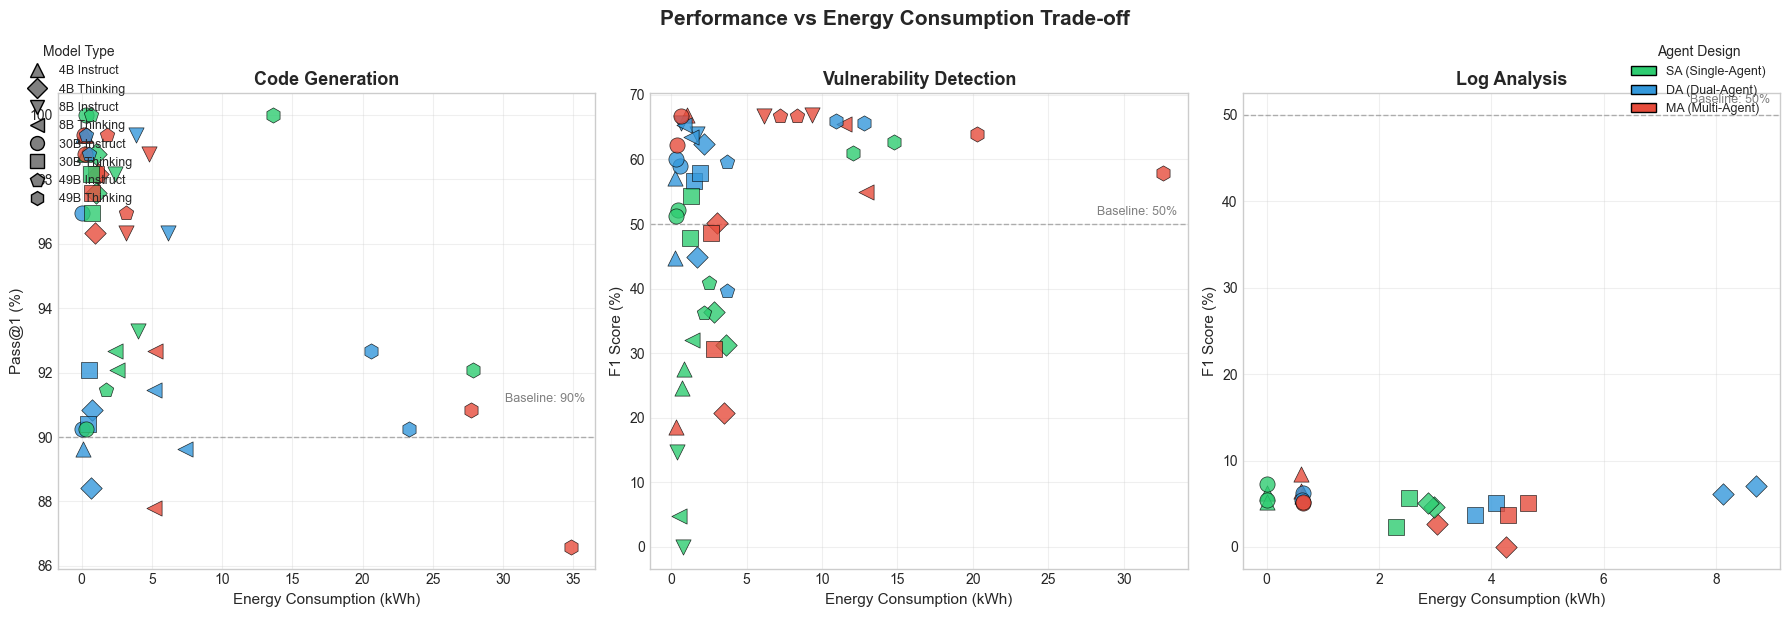


Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/performance_vs_energy_scatter.png


In [22]:
# Create scatter plots for each task
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, task in enumerate(tasks_order):
    ax = axes[idx]
    task_df = merged_df[merged_df['task'] == task].copy()
    
    if len(task_df) == 0:
        ax.text(0.5, 0.5, f'No data for {TASK_LABELS[task]}', 
                ha='center', va='center', transform=ax.transAxes)
        continue
    
    y_label = METRIC_LABELS[task]
    baseline = BASELINES.get(task)
    
    # Create scatter plot
    create_scatter_plot(ax, task_df, task, y_label, baseline)

# Create legend for markers (model types)
marker_legend_elements = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='4B Instruct'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='4B Thinking'),
    Line2D([0], [0], marker='v', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='8B Instruct'),
    Line2D([0], [0], marker='<', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='8B Thinking'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='30B Instruct'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='30B Thinking'),
    Line2D([0], [0], marker='p', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='49B Instruct'),
    Line2D([0], [0], marker='h', color='w', markerfacecolor='gray', markersize=10,
           markeredgecolor='black', label='49B Thinking'),
]

# Create legend for colors (agent designs)
color_legend_elements = [
    mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='SA (Single-Agent)'),
    mpatches.Patch(facecolor='#3498db', edgecolor='black', label='DA (Dual-Agent)'),
    mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='MA (Multi-Agent)'),
]

# Add legends to the figure
fig.legend(handles=marker_legend_elements, loc='upper left', 
           bbox_to_anchor=(0.01, 0.98), title='Model Type', fontsize=9, title_fontsize=10)
fig.legend(handles=color_legend_elements, loc='upper right',
           bbox_to_anchor=(0.99, 0.98), title='Agent Design', fontsize=9, title_fontsize=10)

fig.suptitle('Performance vs Energy Consumption Trade-off', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'performance_vs_energy_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\nSaved: {ANALYSIS_DIR / 'performance_vs_energy_scatter.png'}")

### Individual Task Scatter Plots

Separate plots for each task with data point labels for detailed analysis.

In [23]:
def create_individual_scatter(task_name, save_name, marker_legend_loc='upper left', color_legend_loc='upper right'):
    """Create an individual scatter plot for a specific task with labels.
    
    Args:
        task_name: Name of the task
        save_name: Filename to save the plot
        marker_legend_loc: Location for model type legend (e.g., 'upper left', 'upper right', 'lower right')
        color_legend_loc: Location for agent design legend (e.g., 'upper left', 'upper right', 'lower right')
    """
    
    task_df = merged_df[merged_df['task'] == task_name].copy()
    
    if len(task_df) == 0:
        print(f"No data available for {TASK_LABELS[task_name]}")
        return
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each point with label
    for idx, (_, row) in enumerate(task_df.iterrows()):
        marker = MODEL_TYPE_MARKERS.get((int(row['parameters_b']), row['mode']), 'o')
        color = DESIGN_COLORS_SCATTER.get(row['design'], 'gray')
        
        ax.scatter(
            row['total_energy_kwh'],
            row['primary_metric_pct'],
            marker=marker,
            c=color,
            s=150,
            edgecolors='black',
            linewidths=0.8,
            alpha=0.85,
            zorder=3
        )
        
        # Add label near point
        label = f"{int(row['parameters_b'])}B-{row['mode'][0].upper()}-{row['prompting'][0].upper()}"
        ax.annotate(
            label,
            (row['total_energy_kwh'], row['primary_metric_pct']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=7,
            alpha=0.8
        )
    
    # Add baseline
    baseline = BASELINES.get(task_name)
    if baseline:
        ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
        ax.text(ax.get_xlim()[1] * 0.02, baseline + 1, f'Baseline: {baseline}%', 
                ha='left', va='bottom', fontsize=10, color='gray', fontweight='bold')
    
    ax.set_xlabel('Energy Consumption (kWh)', fontsize=12)
    ax.set_ylabel(METRIC_LABELS[task_name], fontsize=12)
    ax.set_title(f'{TASK_LABELS[task_name]}: Performance vs Energy Trade-off', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, zorder=0)
    
    # Create legends
    marker_elements = [
        Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, 
               markeredgecolor='black', label='4B Instruct'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='4B Thinking'),
        Line2D([0], [0], marker='v', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='8B Instruct'),
        Line2D([0], [0], marker='<', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='8B Thinking'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='30B Instruct'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='30B Thinking'),
        Line2D([0], [0], marker='p', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='49B Instruct'),
        Line2D([0], [0], marker='h', color='w', markerfacecolor='gray', markersize=10,
               markeredgecolor='black', label='49B Thinking'),
    ]
    
    color_elements = [
        mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='SA (Single-Agent)'),
        mpatches.Patch(facecolor='#3498db', edgecolor='black', label='DA (Dual-Agent)'),
        mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='MA (Multi-Agent)'),
    ]
    
    # Add legends with custom positions
    legend1 = ax.legend(handles=marker_elements, loc=marker_legend_loc, title='Model Type', fontsize=9)
    ax.add_artist(legend1)
    ax.legend(handles=color_elements, loc=color_legend_loc, title='Agent Design', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(ANALYSIS_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {ANALYSIS_DIR / save_name}")
    
    # Print statistics
    print(f"\n{TASK_LABELS[task_name]} Statistics:")
    print(f"  Data points: {len(task_df)}")
    print(f"  Energy range: {task_df['total_energy_kwh'].min():.3f} - {task_df['total_energy_kwh'].max():.3f} kWh")
    print(f"  Performance range: {task_df['primary_metric_pct'].min():.2f}% - {task_df['primary_metric_pct'].max():.2f}%")

print("Individual scatter plot function defined with custom legend positions.")

Individual scatter plot function defined with custom legend positions.


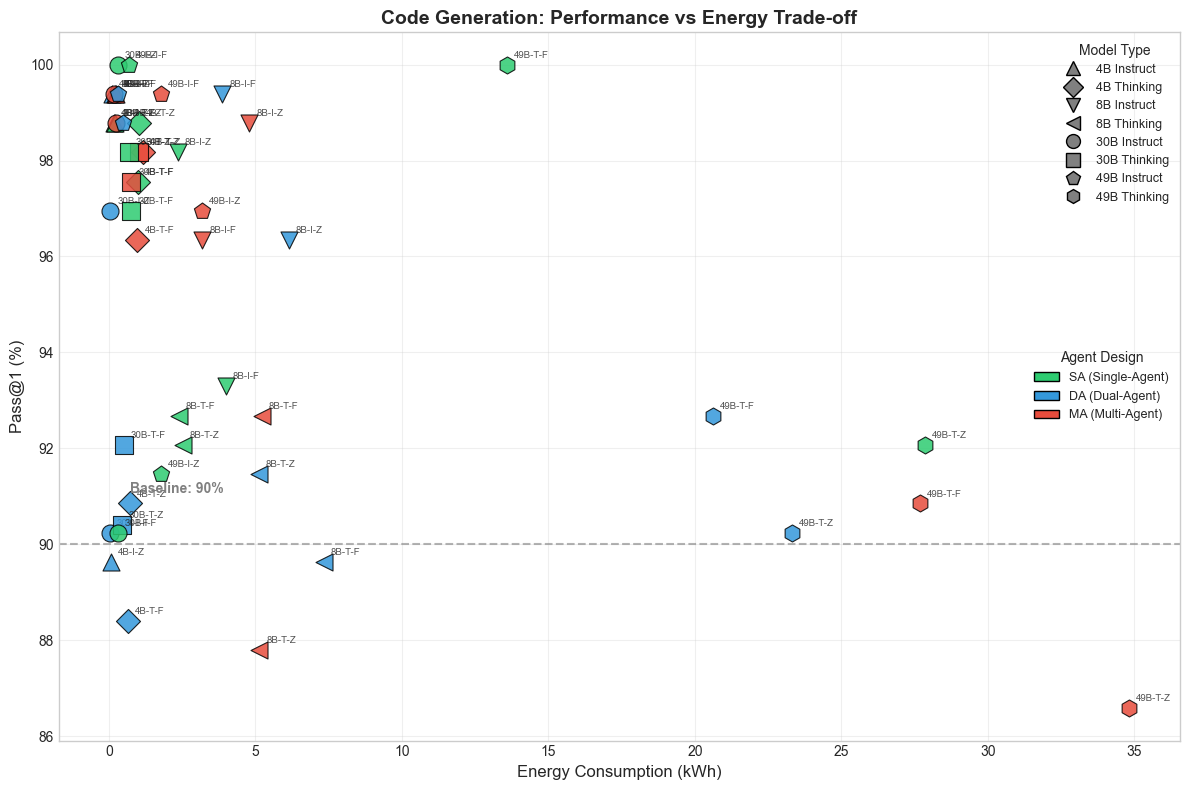

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/scatter_code_generation_energy.png

Code Generation Statistics:
  Data points: 48
  Energy range: 0.028 - 34.820 kWh
  Performance range: 86.59% - 100.00%


In [24]:
# Code Generation: Pass@1 vs Energy (legends at top right)
create_individual_scatter('code_generation', 'scatter_code_generation_energy.png', 
                          marker_legend_loc='upper right', color_legend_loc='right')

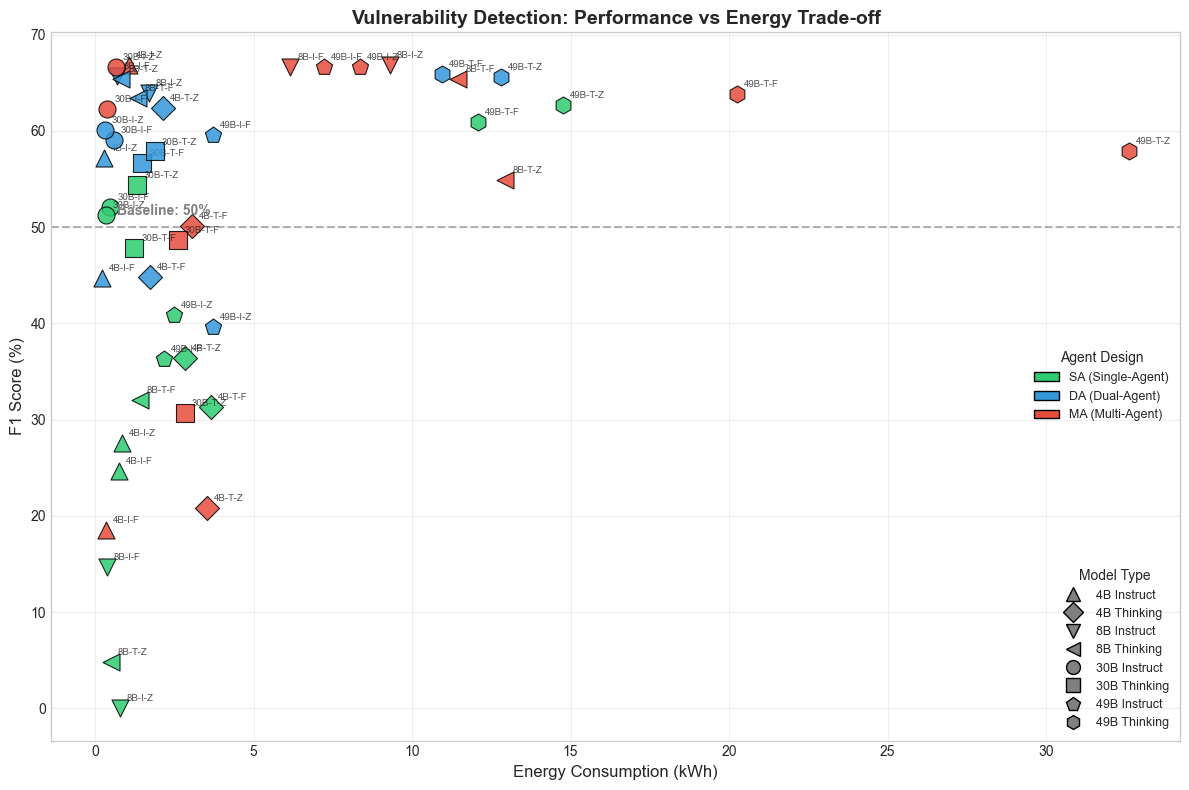

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/scatter_vulnerability_detection_energy.png

Vulnerability Detection Statistics:
  Data points: 48
  Energy range: 0.227 - 32.603 kWh
  Performance range: 0.00% - 66.90%


In [25]:
# Vulnerability Detection: F1 vs Energy (legends at bottom right)
create_individual_scatter('vulnerability_detection', 'scatter_vulnerability_detection_energy.png',
                          marker_legend_loc='lower right', color_legend_loc='right')

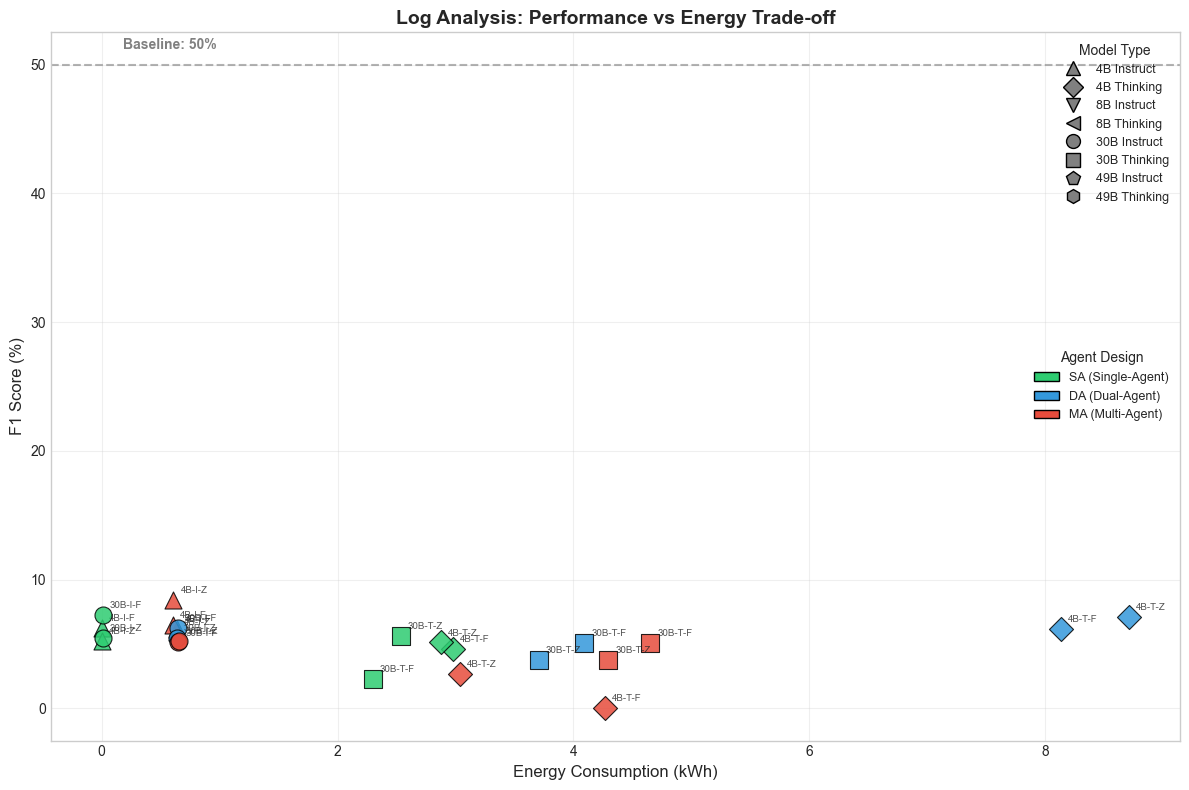

Saved: /Users/shanetan/Documents/Code_Projects/SMU/SCIS_EngD/agent-green/results/analysis_comprehensive/scatter_log_analysis_energy.png

Log Analysis Statistics:
  Data points: 24
  Energy range: 0.006 - 8.706 kWh
  Performance range: 0.00% - 8.45%


In [26]:
# Log Analysis: F1 vs Energy (legends at top right)
create_individual_scatter('log_analysis', 'scatter_log_analysis_energy.png',
                          marker_legend_loc='upper right', color_legend_loc='right')

In [27]:
# Efficiency Analysis: Performance per kWh
print("="*80)
print("EFFICIENCY ANALYSIS: Performance per kWh")
print("="*80)

for task in tasks_order:
    task_df = merged_df[merged_df['task'] == task].copy()
    
    if len(task_df) == 0:
        print(f"\n{TASK_LABELS[task]}: No data")
        continue
    
    # Calculate efficiency (performance per kWh)
    task_df['efficiency'] = task_df['primary_metric_pct'] / task_df['total_energy_kwh']
    
    # Find most efficient configurations
    top_efficient = task_df.nlargest(3, 'efficiency')[['short_label', 'design', 'primary_metric_pct', 'total_energy_kwh', 'efficiency']]
    
    print(f"\n{TASK_LABELS[task]} - Top 3 Most Efficient Configurations:")
    print("-" * 70)
    for _, row in top_efficient.iterrows():
        print(f"  {row['short_label']} | {row['design']} | {row['primary_metric_pct']:.1f}% | {row['total_energy_kwh']:.3f} kWh | {row['efficiency']:.2f} %/kWh")

print("\n" + "="*80)
print("PARETO OPTIMAL CONFIGURATIONS (High Performance, Low Energy)")
print("="*80)

for task in tasks_order:
    task_df = merged_df[merged_df['task'] == task].copy()
    
    if len(task_df) == 0:
        continue
    
    # Simple Pareto front identification
    pareto = []
    for _, row in task_df.iterrows():
        dominated = False
        for _, other in task_df.iterrows():
            # Check if other dominates this row (higher performance AND lower energy)
            if (other['primary_metric_pct'] > row['primary_metric_pct'] and 
                other['total_energy_kwh'] < row['total_energy_kwh']):
                dominated = True
                break
        if not dominated:
            pareto.append(row)
    
    pareto_df = pd.DataFrame(pareto)
    print(f"\n{TASK_LABELS[task]} - Pareto Optimal ({len(pareto_df)} configs):")
    for _, row in pareto_df.iterrows():
        print(f"  {row['short_label']} | {row['design']} | {row['primary_metric_pct']:.1f}% | {row['total_energy_kwh']:.3f} kWh")

EFFICIENCY ANALYSIS: Performance per kWh

Code Generation - Top 3 Most Efficient Configurations:
----------------------------------------------------------------------
  30B-I-F | DA | 90.2% | 0.028 kWh | 3258.52 %/kWh
  30B-I-Z | DA | 97.0% | 0.049 kWh | 1978.05 %/kWh
  4B-I-Z | DA | 89.6% | 0.063 kWh | 1427.97 %/kWh

Vulnerability Detection - Top 3 Most Efficient Configurations:
----------------------------------------------------------------------
  4B-I-Z | DA | 57.1% | 0.277 kWh | 206.31 %/kWh
  4B-I-F | DA | 44.8% | 0.227 kWh | 197.59 %/kWh
  30B-I-Z | DA | 60.1% | 0.317 kWh | 189.63 %/kWh

Log Analysis - Top 3 Most Efficient Configurations:
----------------------------------------------------------------------
  4B-I-Z | SA | 5.2% | 0.006 kWh | 938.24 %/kWh
  4B-I-F | SA | 6.3% | 0.007 kWh | 935.54 %/kWh
  30B-I-F | SA | 7.3% | 0.011 kWh | 643.64 %/kWh

PARETO OPTIMAL CONFIGURATIONS (High Performance, Low Energy)

Code Generation - Pareto Optimal (10 configs):
  4B-I-F | DA | 99